# Loading data

In [1]:
import pandas as pd
from database import load_rent_items
from data_cleaning import geocode_dataframe

In [2]:
raw_df = pd.DataFrame(load_rent_items())
raw_df.set_index("id", drop=True, inplace=True)
raw_df.drop(["href", "href_visited", "title", "street", "description"], axis=1, inplace=True)
raw_df.head()

,publish_date,price,city,district,microdistrict,floor,max_floors,area,rooms
id,,,,,,,,,
5425448230047,2026-06-01,400.0,Beograd,Opština Savski venac,Balkanska,VPR,4,30.0,1.0
5425493439940,2026-06-01,420.0,Beograd,Opština Zemun,Altina,I,2,55.0,2.0
5425620505728,2026-06-05,880.0,Beograd,Opština Vračar,Krunska,IV,6,54.0,2.0
5425634098913,2026-06-08,1600.0,Beograd,Opština Vračar,Hram svetog Save,III,NaN,122.0,3.0
5425634252626,2026-06-01,200.0,Beograd,Opština Rakovica,Kneževac,I,2,20.0,1.0


In [3]:
print(f"{len(raw_df)} listings collected from {raw_df["publish_date"].min()} to {raw_df["publish_date"].max()}")

3231 listings collected from 2026-05-25 to 2026-06-09


# Geocoding locations

In [4]:
unique_locations = raw_df[["city", "district", "microdistrict"]].dropna().agg(', '.join, axis=1).unique()
len(unique_locations)

288

In [5]:
geocoded_df = geocode_dataframe(raw_df, cols=["city", "district", "microdistrict"])
geocoded_df.head()

,publish_date,price,city,district,microdistrict,floor,max_floors,area,rooms,location,lat,lng
id,,,,,,,,,,,,
5425448230047,2026-06-01,400.0,Beograd,Opština Savski venac,Balkanska,VPR,4,30.0,1.0,"Beograd, Opština Savski venac, Balkanska",44.778287,20.458265
5425493439940,2026-06-01,420.0,Beograd,Opština Zemun,Altina,I,2,55.0,2.0,"Beograd, Opština Zemun, Altina",44.855914,20.354030
5425620505728,2026-06-05,880.0,Beograd,Opština Vračar,Krunska,IV,6,54.0,2.0,"Beograd, Opština Vračar, Krunska",44.805264,20.470267
5425634098913,2026-06-08,1600.0,Beograd,Opština Vračar,Hram svetog Save,III,NaN,122.0,3.0,"Beograd, Opština Vračar, Hram svetog Save",44.798138,20.469047
5425634252626,2026-06-01,200.0,Beograd,Opština Rakovica,Kneževac,I,2,20.0,1.0,"Beograd, Opština Rakovica, Kneževac",44.731847,20.429849


# Cleaning data

In [8]:
geocoded_df.isna().sum()

publish_date       0
price              0
city               0
district           0
microdistrict      0
floor            113
max_floors       628
area               0
rooms             27
location           0
lat                0
lng                0
dtype: int64

In [9]:
clean_df = geocoded_df.dropna(subset=["floor", "rooms"]) # dropping listings that account for less than 5% of data
clean_df.isna().sum()

publish_date       0
price              0
city               0
district           0
microdistrict      0
floor              0
max_floors       510
area               0
rooms              0
location           0
lat                0
lng                0
dtype: int64

Not imputing or dropping missing max_floors data here,
will decide on cleaning strategy later on per-model basis.

In [10]:
clean_df.drop(["city", "district", "microdistrict"], axis=1, inplace=True)
clean_df.head()

,publish_date,price,floor,max_floors,area,rooms,location,lat,lng
id,,,,,,,,,
5425448230047,2026-06-01,400.0,VPR,4,30.0,1.0,"Beograd, Opština Savski venac, Balkanska",44.778287,20.458265
5425493439940,2026-06-01,420.0,I,2,55.0,2.0,"Beograd, Opština Zemun, Altina",44.855914,20.354030
5425620505728,2026-06-05,880.0,IV,6,54.0,2.0,"Beograd, Opština Vračar, Krunska",44.805264,20.470267
5425634098913,2026-06-08,1600.0,III,NaN,122.0,3.0,"Beograd, Opština Vračar, Hram svetog Save",44.798138,20.469047
5425634252626,2026-06-01,200.0,I,2,20.0,1.0,"Beograd, Opština Rakovica, Kneževac",44.731847,20.429849


In [11]:
clean_df["floor"].unique()

<StringArray>
[  'VPR',     'I',    'IV',   'III',    'PR',   'VII',    'II',  'PSUT',
  'VIII',    'IX',     'V',    'VI',    'XI',     'X',   'XII',    'XV',
  'XXII', 'XXVII',   'XIV',   'SUT', 'XXIII',  'XIII',   'XVI',  'XXIX',
   'XXX',   'XIX',  'XVII', 'XVIII',   'XXI',    'XX',   'XXV']
Length: 31, dtype: str

In [12]:
from data_cleaning import parse_floor

In [13]:
clean_df['floor'] = clean_df['floor'].apply(parse_floor)
clean_df["floor"].unique()

array([ 0.5,  1. ,  4. ,  3. ,  0. ,  7. ,  2. , -0.5,  8. ,  9. ,  5. ,
        6. , 11. , 10. , 12. , 15. , 22. , 27. , 14. , -1. , 23. , 13. ,
       16. , 29. , 30. , 19. , 17. , 18. , 21. , 20. , 25. ])

In [14]:
clean_df.shape

(3091, 9)

In [15]:
clean_df.head()

,publish_date,price,floor,max_floors,area,rooms,location,lat,lng
id,,,,,,,,,
5425448230047,2026-06-01,400.0,0.5,4,30.0,1.0,"Beograd, Opština Savski venac, Balkanska",44.778287,20.458265
5425493439940,2026-06-01,420.0,1.0,2,55.0,2.0,"Beograd, Opština Zemun, Altina",44.855914,20.354030
5425620505728,2026-06-05,880.0,4.0,6,54.0,2.0,"Beograd, Opština Vračar, Krunska",44.805264,20.470267
5425634098913,2026-06-08,1600.0,3.0,NaN,122.0,3.0,"Beograd, Opština Vračar, Hram svetog Save",44.798138,20.469047
5425634252626,2026-06-01,200.0,1.0,2,20.0,1.0,"Beograd, Opština Rakovica, Kneževac",44.731847,20.429849


In [16]:
clean_df.to_csv("data/data_clean.csv")

# Geospatial price distribution visualization

In [17]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

In [18]:
clean_df["ppm"] = clean_df["price"] / clean_df["area"]  # price in EUR per square meter

In [19]:
grouped_df = clean_df.groupby("location").agg(
    count=("ppm", "size"),
    median_ppm=("ppm", "median")
).reset_index()
grouped_df.head()

,location,count,median_ppm
0,"Beograd, Opština Grocka, Kaluđerica",16,7.795139
1,"Beograd, Opština Grocka, Leštane",3,5.000000
2,"Beograd, Opština Mladenovac, Mladenovac (mesto)",3,5.909091
3,"Beograd, Opština Novi Beograd, Arena",16,11.992481
4,"Beograd, Opština Novi Beograd, Bežanijska kosa 1",12,11.470985


In [20]:
grouped_df = geocode_dataframe(grouped_df, "location")
grouped_df.head()

,location,count,median_ppm,lat,lng
0,"Beograd, Opština Grocka, Kaluđerica",16,7.795139,44.752283,20.555933
1,"Beograd, Opština Grocka, Leštane",3,5.000000,44.730684,20.575564
2,"Beograd, Opština Mladenovac, Mladenovac (mesto)",3,5.909091,44.436436,20.693852
3,"Beograd, Opština Novi Beograd, Arena",16,11.992481,44.814434,20.421276
4,"Beograd, Opština Novi Beograd, Bežanijska kosa 1",12,11.470985,44.818063,20.375494


In [21]:
gdf = gpd.GeoDataFrame(
    grouped_df,
    geometry=[Point(lng, lat) for lat, lng in zip(grouped_df["lat"], grouped_df["lng"])],
    crs="EPSG:4326"             # standard Coordinate Reference System used by GPS
)
gdf = gdf.to_crs("EPSG:3857")   # CRS used for flat maps, reprojecting Earth sufrace lng and lat to flat map coordinates in meters

In [22]:
x = gdf.geometry.x
y = gdf.geometry.y
mask = (
    x.between(np.percentile(x, 5), np.percentile(x, 95)) &  # removing bottom and top 5% of spatial outliers
    y.between(np.percentile(y, 5), np.percentile(y, 95))
)
gdf = gdf[mask]

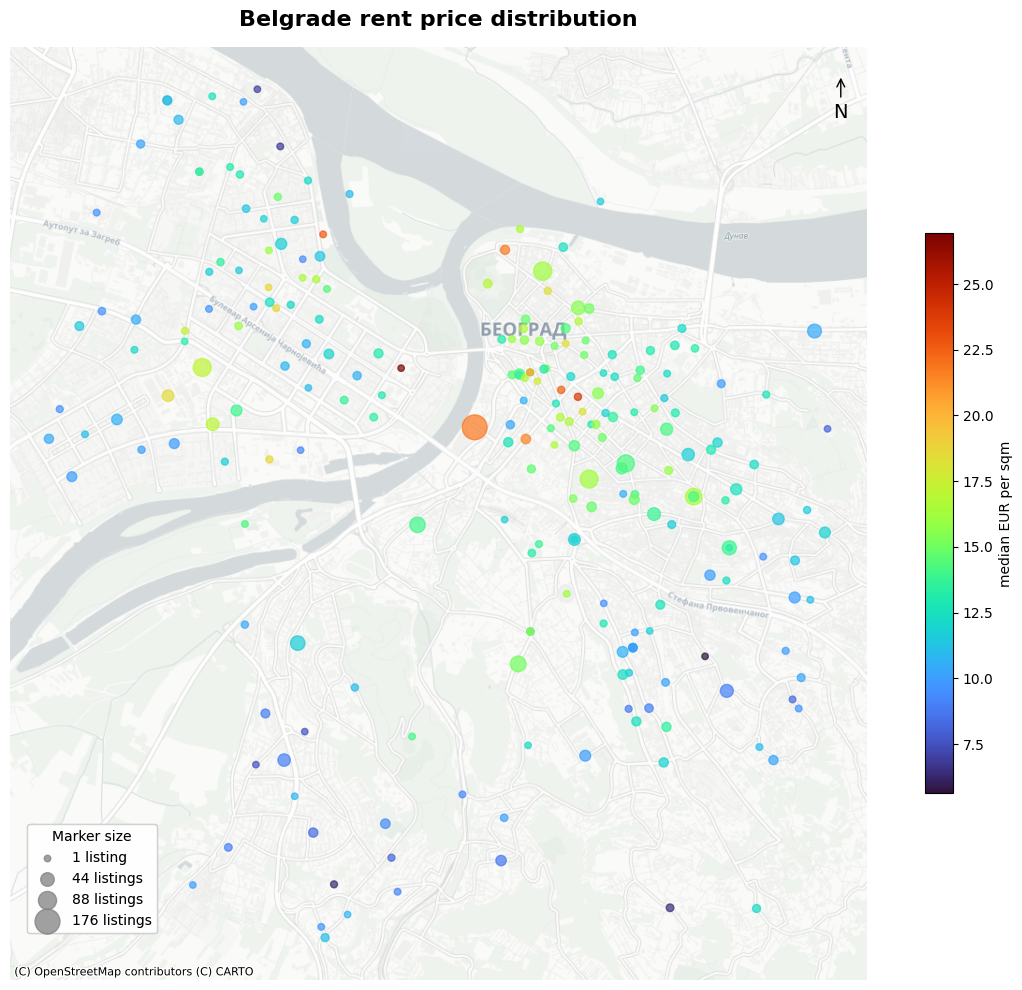

In [23]:
fig, ax = plt.subplots(figsize=(12, 10))

max_count = gdf["count"].max()
marker_sizes = (gdf["count"] / max_count) * 300 + 20  # min size 20, max 320

gdf.plot(
    ax=ax,
    column="median_ppm",
    cmap="turbo",
    markersize=marker_sizes,
    alpha=0.7,
    legend=True,
    legend_kwds={"shrink": 0.6, "label": "median EUR per sqm"}
)

size_values = [1, int(max_count / 4), int(max_count / 2), max_count]
handles = [
    plt.scatter([], [], s=(v / max_count) * 300 + 20, color="gray", alpha=0.7)
    for v in size_values
]
labels = []
for v in size_values:
    if v > 1:
        labels.append(f"{v} listings")
    else:
        labels.append(f"{v} listing")

legend1 = ax.legend(
    handles,
    labels,
    title="Marker size",
    loc=(0.02, 0.05),
    frameon=True
)
ax.add_artist(legend1)

ax.annotate("N", xy=(0.97, 0.97), xycoords="axes fraction", # North arrow
    fontsize=14, ha="center", va="center",
    arrowprops=dict(arrowstyle="->", color="black"),
    xytext=(0.97, 0.93))
ax.set_title("Belgrade rent price distribution", fontsize=16, fontweight="bold", pad=15)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("price_per_sqm.png", dpi=300, bbox_inches="tight")
plt.show()